In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/insurance.csv')

# Display the first 5 rows of the DataFrame
print("\n--- First 5 rows of the dataset ---")
print(df.head())

# Display basic information about the DataFrame (data types, non-null counts)
print("\n--- Dataset Information ---")
df.info()

# Display descriptive statistics of the DataFrame
print("\n--- Descriptive Statistics ---")
print(df.describe(include='all'))

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- First 5 rows of the dataset ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Descriptive Statistics --

### Data Preprocessing: Encoding Categorical Variables

Since `sex`, `smoker`, and `region` are categorical features, they need to be converted into a numerical format that machine learning models can understand. I will use one-hot encoding for these columns.

In [2]:
# Convert categorical variables to numerical using one-hot encoding
df_processed = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Display the first few rows of the processed DataFrame
print("\n--- Processed DataFrame (first 5 rows) ---")
print(df_processed.head())

# Display information about the processed DataFrame to see new columns
print("\n--- Processed DataFrame Information ---")
df_processed.info()


--- Processed DataFrame (first 5 rows) ---
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

--- Processed DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            ------------

### Exploratory Data Analysis: Visualizations

Now, let's create some visualizations to understand the distributions of key variables and their relationships.

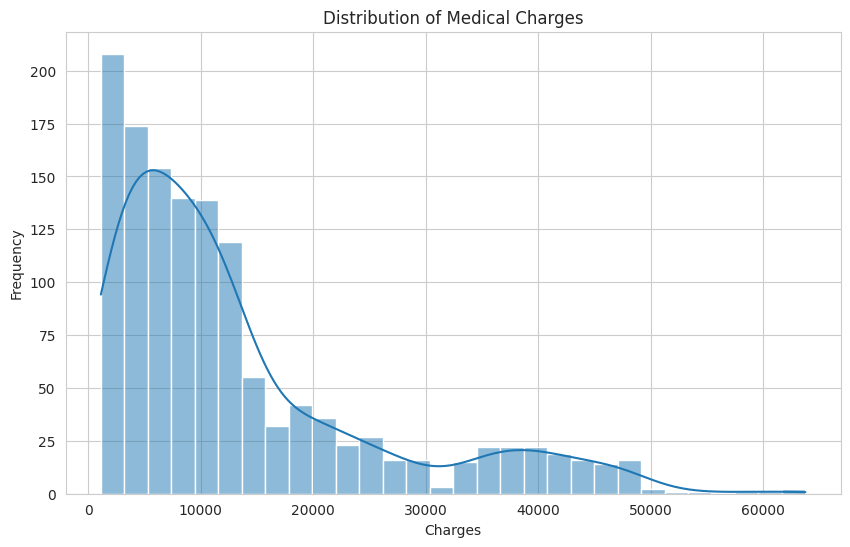

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Distribution of 'charges'
plt.figure(figsize=(10, 6))
sns.histplot(df_processed['charges'], kde=True, bins=30)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()


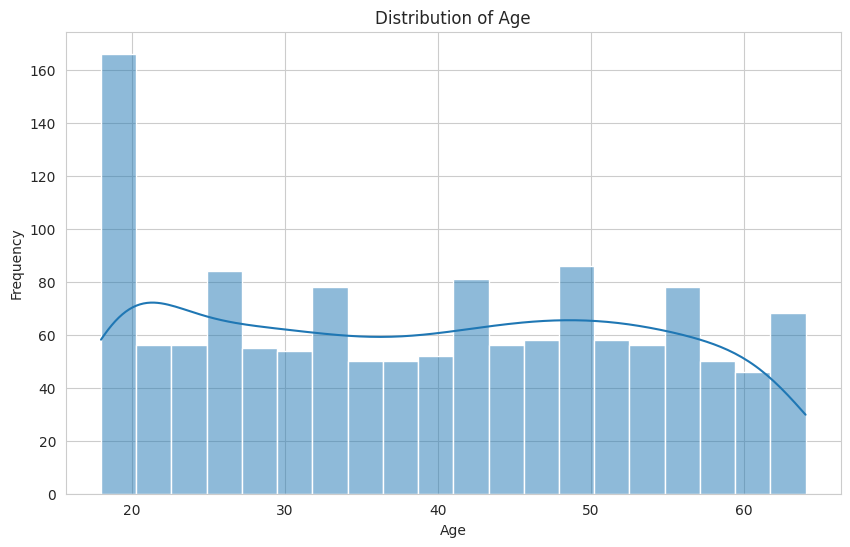

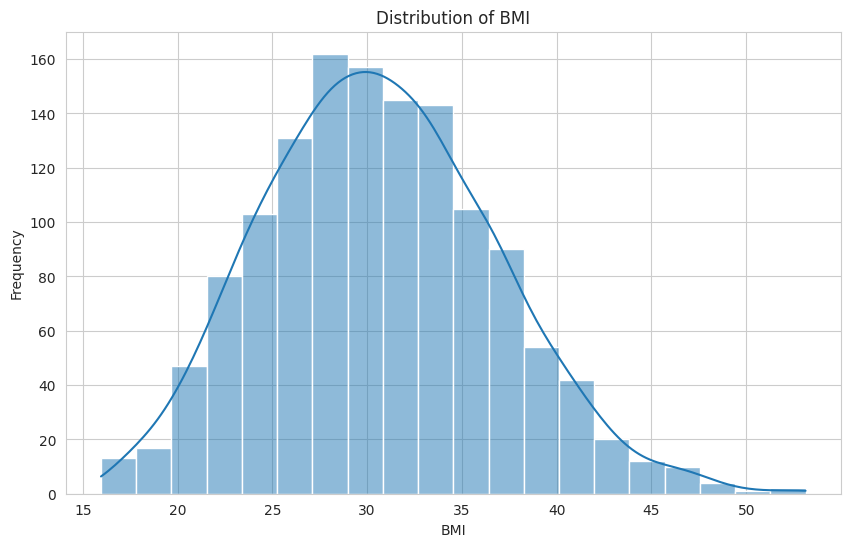

In [4]:
# Distribution of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(df_processed['age'], kde=True, bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Distribution of 'bmi'
plt.figure(figsize=(10, 6))
sns.histplot(df_processed['bmi'], kde=True, bins=20)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()


### Relationships Between Features and Charges

Let's explore how different features relate to the target variable, `charges`.

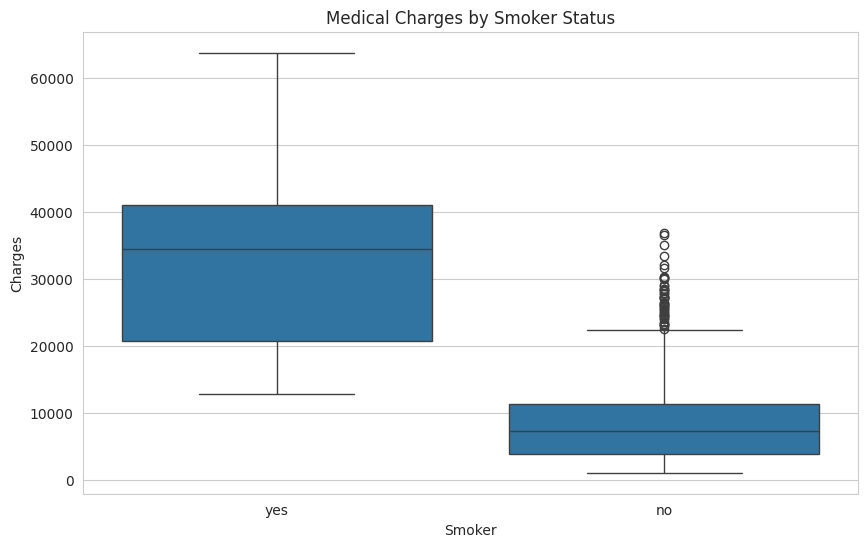

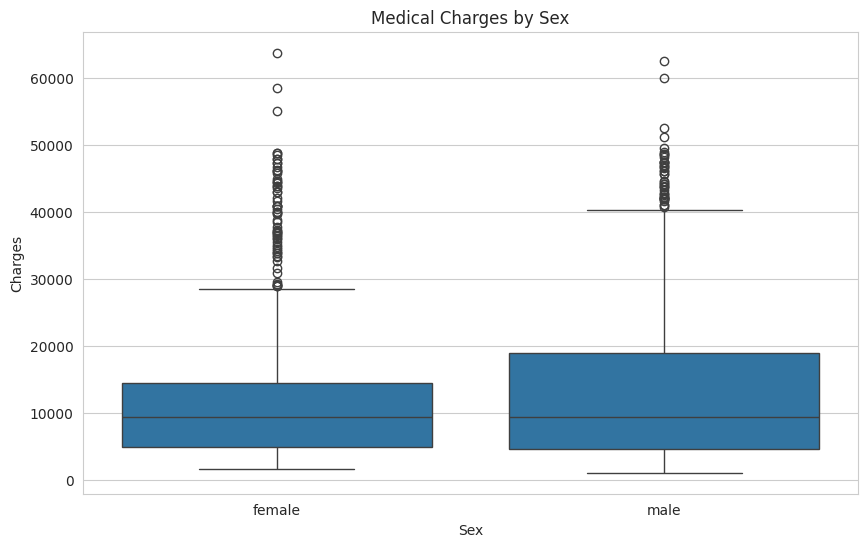

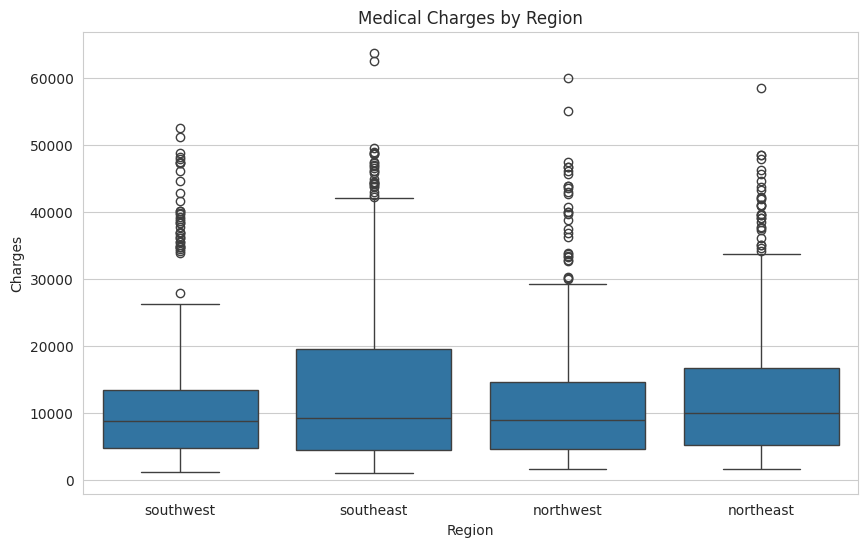

In [7]:
# Relationship between 'smoker' and 'charges'
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Medical Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

# Relationship between 'sex' and 'charges'
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Medical Charges by Sex')
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.show()

# Relationship between 'region' and 'charges'
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Medical Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

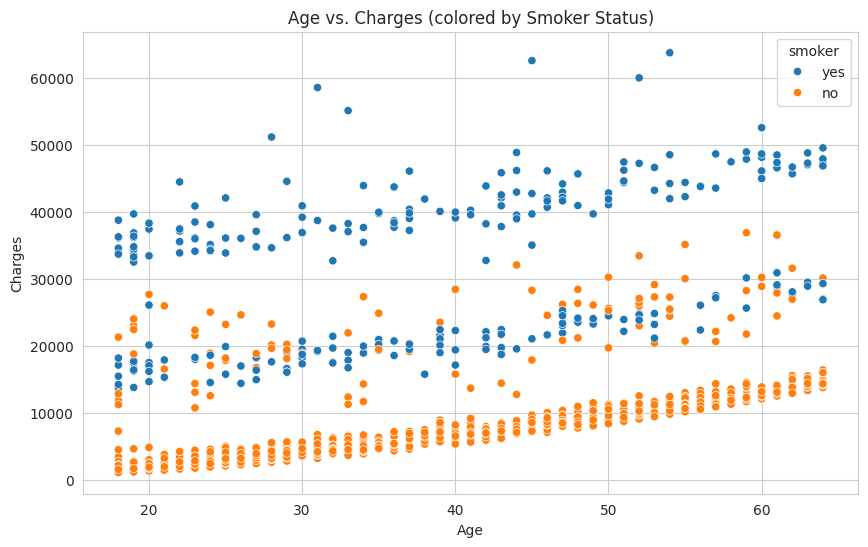

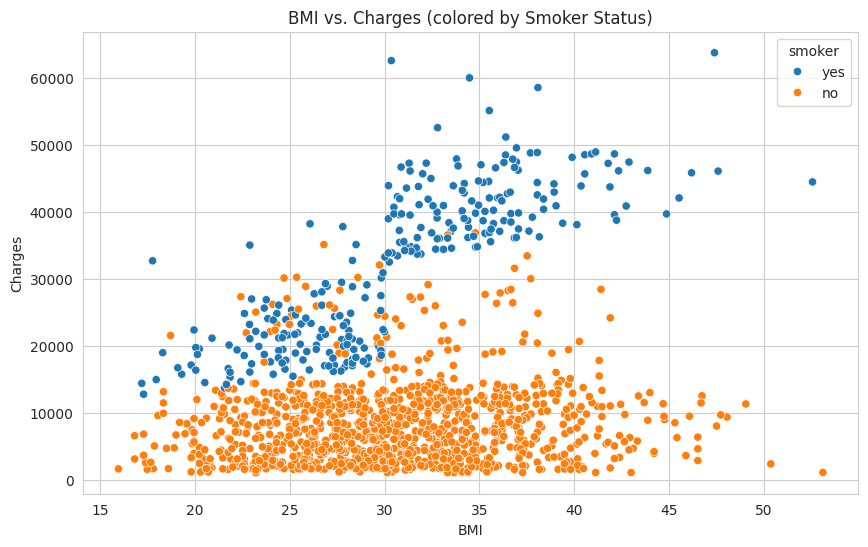

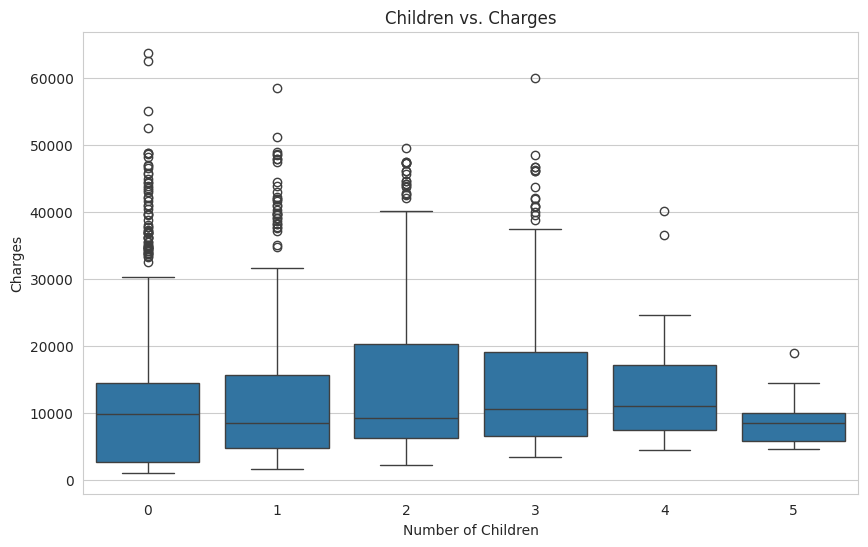

In [8]:
# Scatter plot for 'age' vs 'charges'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Age vs. Charges (colored by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

# Scatter plot for 'bmi' vs 'charges'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs. Charges (colored by Smoker Status)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

# Scatter plot for 'children' vs 'charges'
plt.figure(figsize=(10, 6))
sns.boxplot(x='children', y='charges', data=df)
plt.title('Children vs. Charges')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.show()

### Relationships Between Features and Charges

Let's explore how different features relate to the target variable, `charges`.

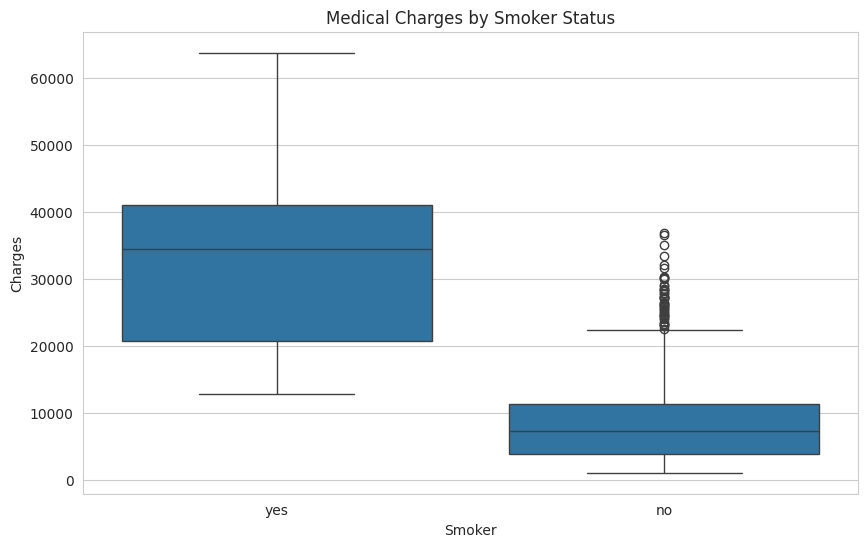

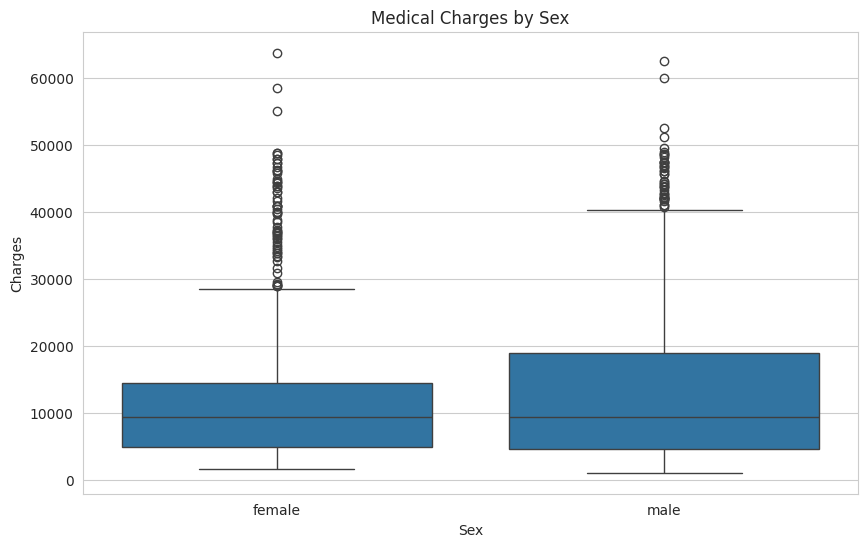

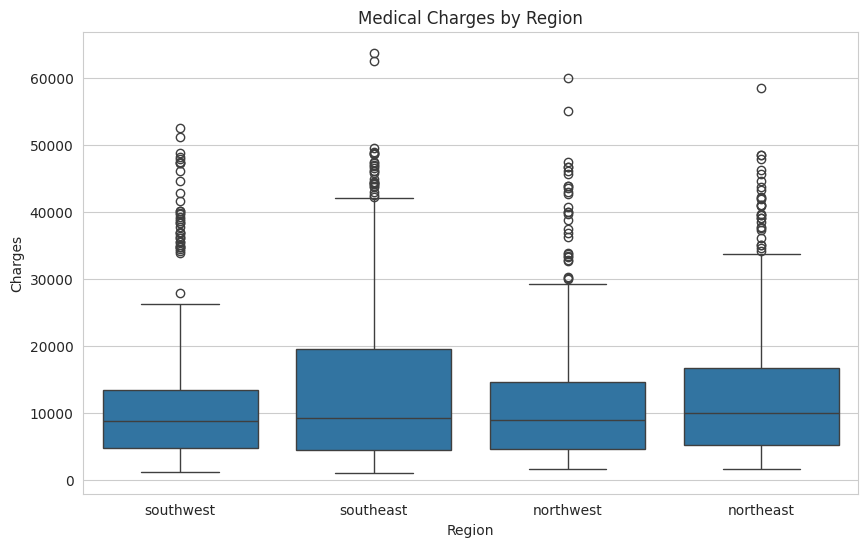

In [5]:
# Relationship between 'smoker' and 'charges'
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Medical Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

# Relationship between 'sex' and 'charges'
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Medical Charges by Sex')
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.show()

# Relationship between 'region' and 'charges'
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Medical Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

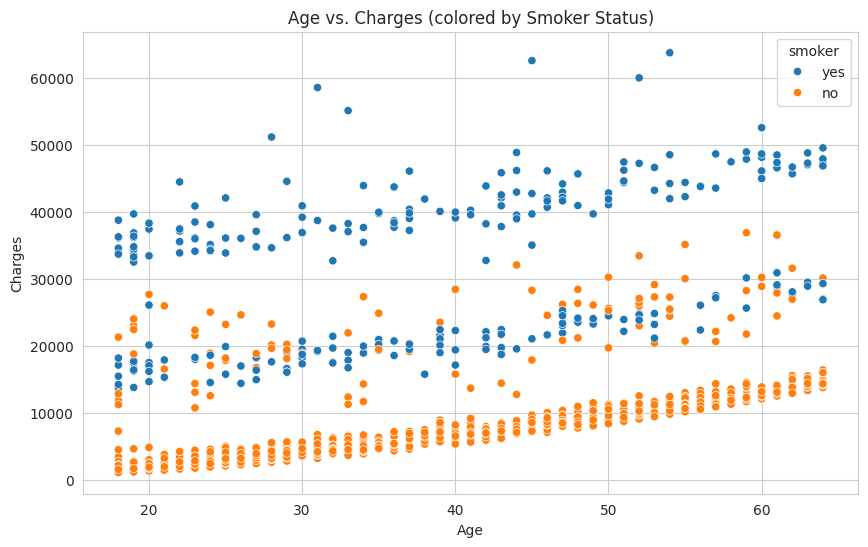

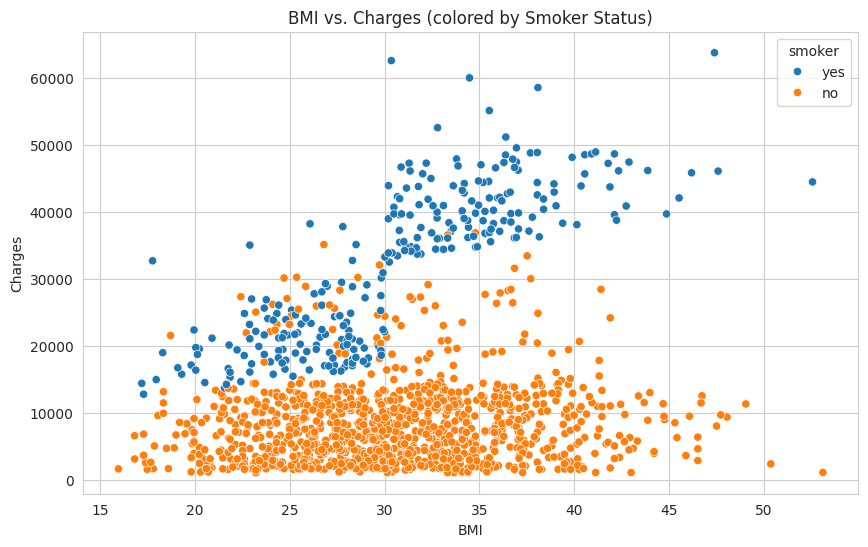

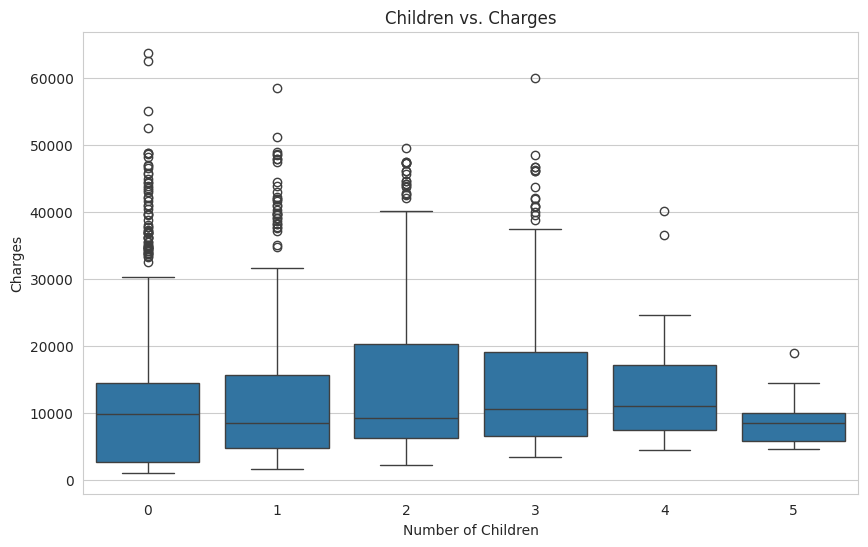

In [6]:
# Scatter plot for 'age' vs 'charges'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Age vs. Charges (colored by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

# Scatter plot for 'bmi' vs 'charges'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs. Charges (colored by Smoker Status)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

# Scatter plot for 'children' vs 'charges'
plt.figure(figsize=(10, 6))
sns.boxplot(x='children', y='charges', data=df)
plt.title('Children vs. Charges')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.show()

### Visualizing the Impact of Age, BMI, and Smoker Status on Charges

<Figure size 1000x600 with 0 Axes>

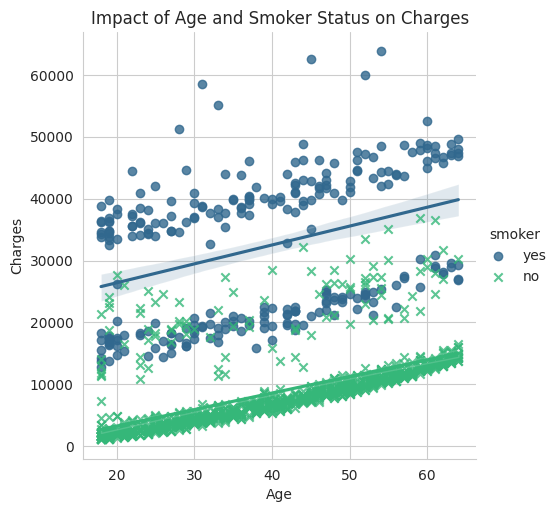

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the impact of 'age' and 'smoker' on 'charges' using lmplot
plt.figure(figsize=(10, 6))
sns.lmplot(x='age', y='charges', hue='smoker', data=df, markers=['o', 'x'], palette='viridis')
plt.title('Impact of Age and Smoker Status on Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()


<Figure size 1000x600 with 0 Axes>

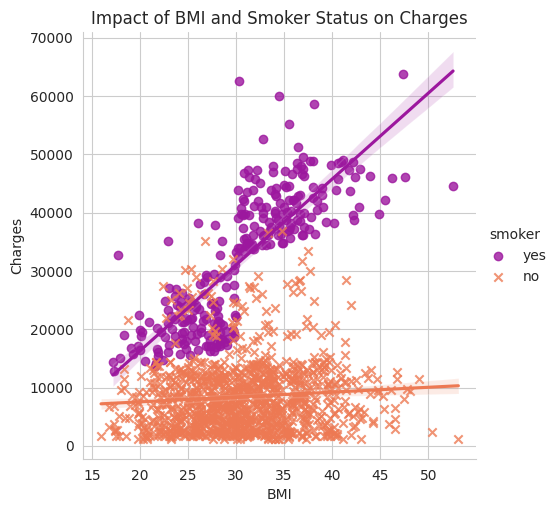

In [13]:
# Visualize the impact of 'bmi' and 'smoker' on 'charges' using lmplot
plt.figure(figsize=(10, 6))
sns.lmplot(x='bmi', y='charges', hue='smoker', data=df, markers=['o', 'x'], palette='plasma')
plt.title('Impact of BMI and Smoker Status on Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()


### Model Building: Linear Regression

Now that the data has been preprocessed and explored, let's build a predictive model. We will use a Linear Regression model as a baseline.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df_processed.drop('charges', axis=1)
y = df_processed['charges']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical columns for scaling (excluding boolean columns created by one-hot encoding)
numerical_cols = ['age', 'bmi', 'children']

# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical features in the training and testing sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Data preparation complete. Shapes of training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data preparation complete. Shapes of training and testing sets:
X_train shape: (1070, 8)
y_train shape: (1070,)
X_test shape: (268, 8)
y_test shape: (268,)


In [10]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

# Display coefficients (feature importance for linear models)
print("\n--- Model Coefficients ---")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))


--- Model Evaluation ---
Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): 5796.28
R-squared (R2): 0.7836

--- Model Coefficients ---
            Feature   Coefficient
4        smoker_yes  23651.128856
0               age   3614.975415
1               bmi   2036.228123
2          children    516.890247
3          sex_male    -18.591692
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


### Model Building: Random Forest Regressor

Let's try a more advanced model, a Random Forest Regressor, to see if we can improve prediction accuracy. Random Forests are ensemble learning methods that can capture complex, non-linear relationships in the data.

In [11]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
# Using a random_state for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Random Forest Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.4f}")

# Display feature importances
print("\n--- Random Forest Feature Importances ---")
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
print(feature_importances.sort_values(by='Importance', ascending=False))


--- Random Forest Model Evaluation ---
Mean Absolute Error (MAE): 2543.98
Mean Squared Error (MSE): 20864569.51
Root Mean Squared Error (RMSE): 4567.78
R-squared (R2): 0.8656

--- Random Forest Feature Importances ---
            Feature  Importance
4        smoker_yes    0.608618
1               bmi    0.216506
0               age    0.134232
2          children    0.019413
3          sex_male    0.006379
5  region_northwest    0.005587
6  region_southeast    0.005314
7  region_southwest    0.003950
